# Sesión 3 — Ver el Modelo y Jugar con la Tarifa
## Módulo 4 · Tema 2: GLM con Python
### Diplomado: Machine Learning en Seguros · FC UNAM
### 28 de agosto de 2026  ·  3 horas

---

> **Premisa:** los modelos ya están ajustados y **guardados** desde la Sesión 2. Hoy los
> ponemos a trabajar: **visualizamos** sus efectos, los **validamos** fuera de muestra,
> entendemos cómo entran **deducible y suma asegurada**, hacemos **análisis de sensibilidad**
> y cerramos con una **simulación de tarifa** de punta a punta.

---

**Prerequisito:** haber corrido la Sesión 2 (existe `modelos/metadatos.json`). Ambiente
`diplomado` con `statsmodels`, `scikit-learn`, `plotly`, `matplotlib`. `cargar_modelos.py` en la carpeta.
Soluciones en `m4t2_s3_soluciones.py`.

## Ruta de la sesión — cinco bloques

| # | Bloque | Idea central |
|---|--------|--------------|
| 1 | Visualización de efectos | Qué le hace cada variable a la prima — curvas de efecto parcial (+ plotly) |
| 2 | Validación out-of-sample | ¿El modelo sirve con datos nuevos? Gini, calibración, lift |
| 3 | Deducible y suma asegurada | Cómo entran a la tarifa · por qué el deducible afecta la frecuencia |
| 4 | Análisis de sensibilidad | ¿Qué pasa con la prima si muevo un factor? |
| 5 | Simulación de tarifa | De prima pura a tarifa · escenarios sobre el portafolio |

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import statsmodels.api as sm, statsmodels.formula.api as smf
import warnings; warnings.filterwarnings('ignore')
from cargar_modelos import cargar_modelos, preparar_datos

AZUL='#0D7A8A'; AMBAR='#F4A261'; GRIS='#8FA3B1'; MORADO='#B07CC6'
plt.rcParams.update({'figure.figsize':(10,5),'axes.grid':True,'grid.alpha':0.25,'axes.axisbelow':True})
pd.set_option('display.float_format','{:,.4f}'.format)

# Cargamos los modelos guardados en la Sesión 2 (reconstrucción exacta)
datos, sev = preparar_datos()
M = cargar_modelos(verbose=True)
modelo_frec, modelo_sev, modelo_agg = M['frecuencia'], M['severidad'], M['agregado']
freq_ref = datos['num_siniestros'].sum()/datos['exposicion'].sum()

frecuencia: 27 params · AIC 124,891
severidad : 24 params · AIC 345,326
agregado  : Tweedie p=1.3 · 20 params


---
# Bloque 1 · Visualización de efectos

Un modelo multivariado tiene decenas de coeficientes; leerlos en una tabla no dice **cómo se
comporta** cada variable. El **efecto parcial** responde eso: fijamos todas las variables en su
nivel de referencia y movemos **solo una**, prediciendo la frecuencia (o severidad) en cada nivel.
Es el equivalente en Python del `plot(Effect())` de R.

$$\hat\mu(\text{nivel}) = \exp\big(\hat\beta_0 + \hat\beta_{\text{nivel}}\big)\quad\text{con el resto en referencia.}$$

In [2]:
# Nivel de referencia de cada variable (categoría base del modelo)
REF = {'cobertura':'Amplia','sexo':'Hombre','uso':'Particular','combustible':'Diesel',
       'edad_conductor_cat':'(35, 45]','antiguedad_vehiculo_cat':'(4, 5]',
       'potencia_cat':'(50, 60]','nivel_bonus_cat':'(-1, 0]'}

def _ordenar(cats):
    return sorted(cats, key=lambda c: float(str(c).split(',')[0].strip('([')) if ',' in str(c) else str(c))

def efecto_parcial(modelo, variable, con_offset=True):
    # Frecuencia esperada moviendo SOLO 'variable', con el resto en referencia
    base = datos.iloc[[0]].copy()
    for k,v in REF.items(): base[k]=v
    base['exposicion']=1.0
    cats=_ordenar(datos[variable].astype(str).unique())
    grid=pd.concat([base.assign(**{variable:c}) for c in cats], ignore_index=True)
    if con_offset:
        pred=modelo.predict(grid, offset=np.log(grid['exposicion']))
    else:
        pred=modelo.predict(grid)
    return pd.DataFrame({variable:cats, 'efecto':pred.values})

ef_edad = efecto_parcial(modelo_frec, 'edad_conductor_cat')
print(ef_edad.round(4).to_string(index=False))

edad_conductor_cat  efecto
          (17, 30]  0.1363
          (30, 35]  0.1192
          (35, 45]  0.1180
          (45, 50]  0.1156
          (50, 55]  0.1113
          (55, 60]  0.1013
          (60, 95]  0.0953


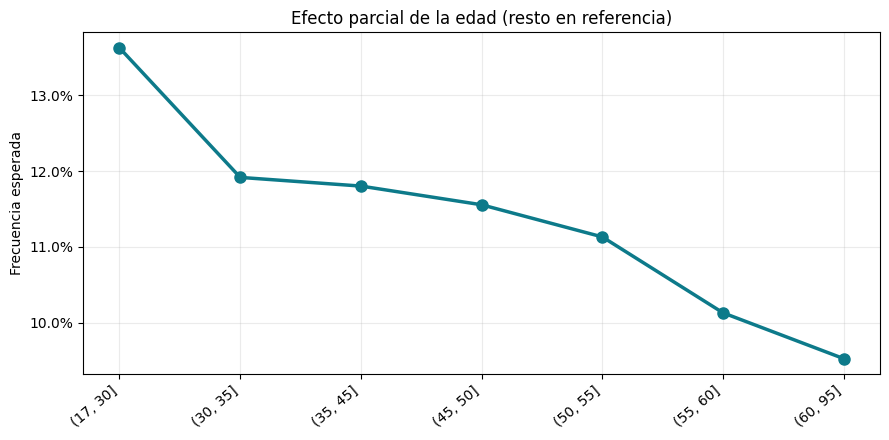

In [3]:
# ── Gráfico estático del efecto parcial ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(range(len(ef_edad)), ef_edad['efecto'], '-o', color=AZUL, lw=2.5, markersize=8)
ax.set_xticks(range(len(ef_edad))); ax.set_xticklabels(ef_edad['edad_conductor_cat'], rotation=40, ha='right')
ax.set(ylabel='Frecuencia esperada', title='Efecto parcial de la edad (resto en referencia)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1%}'))
plt.tight_layout(); plt.show()

In [4]:
# ── Versión INTERACTIVA con plotly ───────────────────────────────────────────
# Compara el efecto de varias variables en una sola figura interactiva (hover, zoom).
fig = go.Figure()
for var in ['edad_conductor_cat','nivel_bonus_cat','potencia_cat']:
    ef = efecto_parcial(modelo_frec, var)
    fig.add_trace(go.Scatter(x=[str(c) for c in ef[var]], y=ef['efecto'],
                             mode='lines+markers', name=var.replace('_cat','')))
fig.add_hline(y=freq_ref, line_dash='dash', line_color='gray',
              annotation_text=f'referencia {freq_ref:.1%}')
fig.update_layout(title='Efectos parciales sobre la frecuencia (interactivo)',
                  xaxis_title='nivel', yaxis_title='frecuencia esperada',
                  yaxis_tickformat='.1%', template='plotly_white', height=450)
fig.show()

### 📝 Ejercicio 1 — El efecto de tu variable (8 min)

- **1a.** Grafica el efecto parcial de `antiguedad_vehiculo_cat` sobre la **frecuencia**.
- **1b.** ¿La forma es monótona o tiene un mínimo/máximo intermedio? ¿Tiene sentido actuarial?
- **1c.** Haz lo mismo para la **severidad** (`modelo_sev`, sin offset). ¿El efecto es más plano?

*Solución en `solucion_ejercicio1()`.*

In [5]:
# Tu código aquí:


---
# Bloque 2 · Validación out-of-sample

El AIC y la devianza se calculan sobre los **mismos** datos con que ajustamos — no detectan
sobreajuste. La prueba de verdad es predecir sobre datos que el modelo **no vio**. Dividimos
80% train / 20% test, reajustamos en train y evaluamos en test con tres métricas complementarias:

- **Ratio predicho/observado** → *calibración* (¿acierta el total?).
- **Coeficiente de Gini** → *discriminación* (¿separa bien alto de bajo riesgo?).
- **Calibración por deciles y lift** → ¿es correcto en cada segmento?

In [6]:
# ── División train / test y reajuste solo en train ───────────────────────────
np.random.seed(42)
idx = np.random.rand(len(datos)) < 0.8
train, test = datos[idx].copy(), datos[~idx].copy()
mod_val = smf.glm(M['meta']['frecuencia']['formula'], train,
                  family=sm.families.Poisson(), offset=np.log(train['exposicion'])).fit()
test['pred'] = mod_val.predict(test, offset=np.log(test['exposicion']))
test['pred_freq'] = test['pred'] / test['exposicion']

# Ratio predicho/observado
ratio = test['pred'].sum() / test['num_siniestros'].sum()

# Coeficiente de Gini (normalizado)
def gini(y, yhat):
    def g(orden):
        s = np.asarray(y, float)[np.argsort(orden)]; n=len(s); tot=s.sum()
        return (2*np.sum(np.cumsum(s)) - (n+1)*tot)/(n*tot)
    return g(yhat)/g(y)
gini_test = gini(test['num_siniestros'].values, test['pred'].values)

print(f'Ratio predicho/observado (test): {ratio:.4f}   (ideal ≈ 1.00 → bien calibrado)')
print(f'Coeficiente de Gini (test):      {gini_test:.4f}   (> 0.30 aceptable → discrimina)')

Ratio predicho/observado (test): 1.0249   (ideal ≈ 1.00 → bien calibrado)
Coeficiente de Gini (test):      0.2315   (> 0.30 aceptable → discrimina)


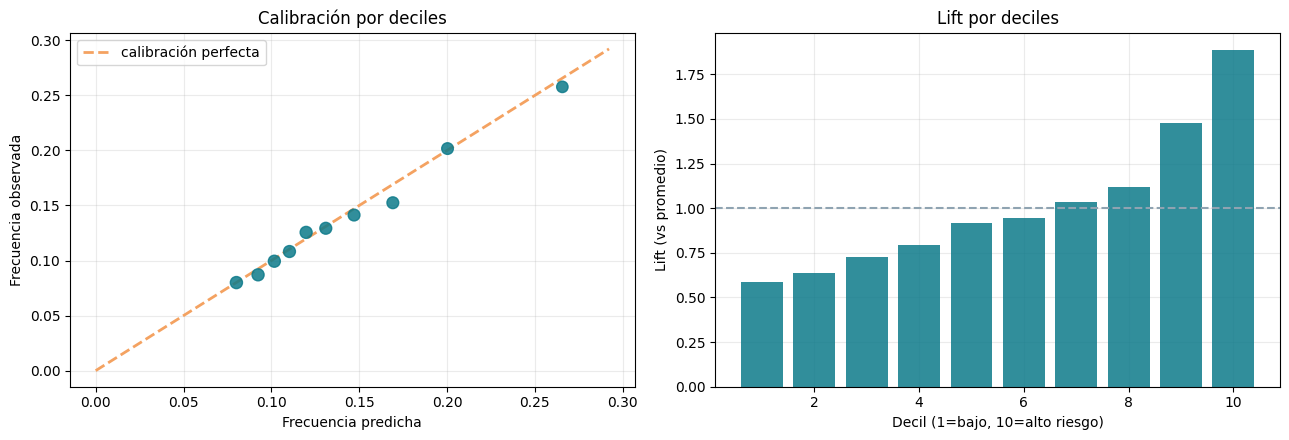

El modelo separa el decil más riesgoso del menos riesgoso por 3.2x


In [7]:
# ── Calibración por deciles + lift ───────────────────────────────────────────
test['decil'] = pd.qcut(test['pred_freq'], 10, labels=False, duplicates='drop')
cal = test.groupby('decil').apply(lambda x: pd.Series({
    'expo':x['exposicion'].sum(),
    'freq_obs':x['num_siniestros'].sum()/x['exposicion'].sum(),
    'freq_pred':x['pred'].sum()/x['exposicion'].sum(),
}), include_groups=False).reset_index()
freq_prom = test['num_siniestros'].sum()/test['exposicion'].sum()
cal['lift_obs'] = cal['freq_obs']/freq_prom

fig, (a1,a2) = plt.subplots(1,2, figsize=(13,4.5))
# calibración
a1.scatter(cal['freq_pred'], cal['freq_obs'], s=cal['expo']/40, color=AZUL, alpha=0.85, zorder=3)
lim=max(cal['freq_pred'].max(),cal['freq_obs'].max())*1.1
a1.plot([0,lim],[0,lim],'--',color=AMBAR,lw=2,label='calibración perfecta')
a1.set(xlabel='Frecuencia predicha', ylabel='Frecuencia observada', title='Calibración por deciles'); a1.legend()
# lift
a2.bar(cal['decil']+1, cal['lift_obs'], color=AZUL, alpha=0.85); a2.axhline(1,ls='--',color=GRIS)
a2.set(xlabel='Decil (1=bajo, 10=alto riesgo)', ylabel='Lift (vs promedio)', title='Lift por deciles')
plt.tight_layout(); plt.show()
print(f'El modelo separa el decil más riesgoso del menos riesgoso por {cal.lift_obs.max()/cal.lift_obs.min():.1f}x')

### 📝 Ejercicio 2 — Interpreta la validación (8 min)

- **2a.** ¿El ratio pred/obs está cerca de 1? ¿Qué significa para la calibración global?
- **2b.** ¿El Gini supera 0.30? Interpreta qué tan bien discrimina el modelo.
- **2c.** Mira la tabla de calibración por deciles: ¿algún decil está mal calibrado (predicho lejos
  de observado)? ¿Qué harías?

*Solución en `solucion_ejercicio2()`.*

In [8]:
# Tu código aquí:


---
# Bloque 3 · Deducible y suma asegurada

Dos variables que el comité técnico de la CNSF suele cuestionar, y que confunden en la práctica.

### Deducible — afecta la FRECUENCIA, no la severidad
El deducible es el monto que absorbe el asegurado antes de que la póliza pague. Su efecto clave:
los siniestros **menores al deducible no se reportan** (no conviene reclamar). Eso **reduce la
frecuencia observada** — y, por selección, cambia la mezcla de montos. Por eso el deducible
entra como **predictor en el modelo de frecuencia**, típicamente categórico o como `log(deducible)`.

### Suma asegurada — afecta la SEVERIDAD (el tope de pago)
La suma asegurada es el máximo que paga la póliza. **No cambia la probabilidad** de siniestro, pero
**sí acota la severidad** (censura por arriba). Entra como predictor en el modelo de **severidad**,
no en el de frecuencia.

In [9]:
# ── Demostración: cómo un deducible reduce la frecuencia reportada ───────────
# Nuestra cartera no trae 'deducible', así que lo SIMULAMOS: un siniestro de monto < D
# no se reporta. Vemos caer la frecuencia y qué pasa con la severidad de los que quedan.
con = datos[datos['num_siniestros'] > 0]
expo_total = datos['exposicion'].sum()
filas = []
for D in [0, 250, 500, 1000, 2000, 5000]:
    reportados = con[con['monto_total'] >= D]
    freq = reportados['num_siniestros'].sum() / expo_total
    sev  = np.average(reportados['severidad'], weights=reportados['num_siniestros']) if len(reportados) else np.nan
    filas.append({'deducible':D, 'freq_reportada':round(freq,4),
                  'sev_media_reportada':round(sev,0), 'pct_siniestros': round(len(reportados)/len(con),3)})
print(pd.DataFrame(filas).to_string(index=False))
print('\nLa frecuencia CAE con el deducible (menos siniestros chicos se reportan);')
print('la severidad media de los que quedan SUBE (quedan los grandes).')

 deducible  freq_reportada  sev_media_reportada  pct_siniestros
         0          0.1392           1,309.0000          1.0000
       250          0.0850           2,069.0000          0.5790
       500          0.0751           2,300.0000          0.5150
      1000          0.0613           2,664.0000          0.4140
      2000          0.0246           4,683.0000          0.1500
      5000          0.0063          11,533.0000          0.0390

La frecuencia CAE con el deducible (menos siniestros chicos se reportan);
la severidad media de los que quedan SUBE (quedan los grandes).


**Para nota técnica CNSF:** documentar explícitamente que el deducible se incluyó en el modelo de
**frecuencia** (por el efecto de no-reporte y selección adversa) y la suma asegurada en el de
**severidad** (como tope). Justificar el tratamiento y la fuente del dato.

### 📝 Ejercicio 3 — El efecto del deducible (10 min)

- **3a.** Repite el análisis con deducibles $750 y $1,500. ¿Cuánto cae la frecuencia en cada uno?
- **3b.** ¿Por qué la severidad media SUBE al aumentar el deducible?
- **3c.** En una frase: ¿por qué el deducible NO debería entrar en el modelo de severidad tal cual?

*Solución en `solucion_ejercicio3()`.*

In [10]:
# Tu código aquí:


---
# Bloque 4 · Análisis de sensibilidad

Antes de fijar una tarifa, hay que saber **qué tan frágil** es a nuestras decisiones. La pregunta:
si muevo un rating factor (o agrupo categorías, o cambio un banding), **¿cuánto se mueve la prima
del portafolio?** Lo medimos aplicando el modelo, perturbando, y recomputando la prima agregada.

In [11]:
# ── Prima pura por póliza = frecuencia × severidad ───────────────────────────
datos['freq_pred'] = modelo_frec.predict(datos, offset=np.log(datos['exposicion'])) / datos['exposicion']
datos['sev_pred']  = modelo_sev.predict(datos)
datos['pp']        = datos['freq_pred'] * datos['sev_pred']
prima_base = np.average(datos['pp'], weights=datos['exposicion'])
print(f'Prima pura media del portafolio: ${prima_base:,.2f}')

Prima pura media del portafolio: $182.34


In [12]:
# ── Sensibilidad: ¿qué pasa si recargo un factor un +10%? ────────────────────
def sensibilidad_factor(columna, nivel, cambio_pct):
    # Aplica un cambio % al rating factor de un nivel y mide el impacto en la prima agregada
    d = datos.copy()
    mask = d[columna].astype(str) == nivel
    d.loc[mask, 'pp'] = d.loc[mask, 'pp'] * (1 + cambio_pct/100)
    prima_nueva = np.average(d['pp'], weights=d['exposicion'])
    return prima_nueva, (prima_nueva/prima_base - 1)*100

for niv, chg in [('(17, 30]', 10), ('(17, 30]', -10), ('(60, 95]', 10)]:
    nueva, imp = sensibilidad_factor('edad_conductor_cat', niv, chg)
    print(f'Recargo {chg:+d}% a edad {niv:10}: prima portafolio ${nueva:,.2f}  ({imp:+.2f}% agregado)')
print('\nEl impacto agregado depende de la EXPOSICIÓN del segmento: mover un grupo chico casi no mueve el total.')

Recargo +10% a edad (17, 30]  : prima portafolio $186.87  (+2.49% agregado)
Recargo -10% a edad (17, 30]  : prima portafolio $177.80  (-2.49% agregado)
Recargo +10% a edad (60, 95]  : prima portafolio $185.20  (+1.57% agregado)

El impacto agregado depende de la EXPOSICIÓN del segmento: mover un grupo chico casi no mueve el total.


### 📝 Ejercicio 4 — Sensibilidad de otro factor (10 min)

- **4a.** Mide el impacto agregado de recargar +15% el nivel de mayor `nivel_bonus_cat`.
- **4b.** Compáralo con recargar +15% un nivel de baja exposición. ¿Cuál mueve más la prima total y por qué?
- **4c.** ¿Qué te dice esto sobre dónde conviene afinar la tarifa?

*Solución en `solucion_ejercicio4()`.*

In [13]:
# Tu código aquí:


---
# Bloque 5 · Simulación de tarifa

El cierre del tema: de la **prima pura** (el costo esperado del riesgo) a una **prima de tarifa**
(lo que cobras). La prima de tarifa carga sobre la prima pura los **gastos** y el **margen**:
$$\text{Prima de tarifa} = \frac{\text{Prima pura}}{1 - \text{gastos}\% - \text{margen}\%}.$$
Con eso simulamos escenarios sobre todo el portafolio.

In [14]:
# ── De prima pura a prima de tarifa ──────────────────────────────────────────
GASTOS = 0.25     # 25% de gastos
MARGEN = 0.05     # 5% de margen
recargo = 1/(1 - GASTOS - MARGEN)

datos['prima_tarifa'] = datos['pp'] * recargo
prima_pura_total   = (datos['pp'] * datos['exposicion']).sum()
prima_tarifa_total = (datos['prima_tarifa'] * datos['exposicion']).sum()
print(f'Recargo comercial: ×{recargo:.3f}')
print(f'Prima pura total del portafolio:   ${prima_pura_total:,.0f}')
print(f'Prima de tarifa total (con carga): ${prima_tarifa_total:,.0f}')
print(f'Prima de tarifa media por póliza:  ${np.average(datos.prima_tarifa, weights=datos.exposicion):,.2f}')

Recargo comercial: ×1.429
Prima pura total del portafolio:   $26,478,207
Prima de tarifa total (con carga): $37,826,010
Prima de tarifa media por póliza:  $260.48


    escenario   prima_total  variación_%
Tarifa actual 37,826,009.85         0.00
 Tarifa nueva 38,339,407.63         1.36


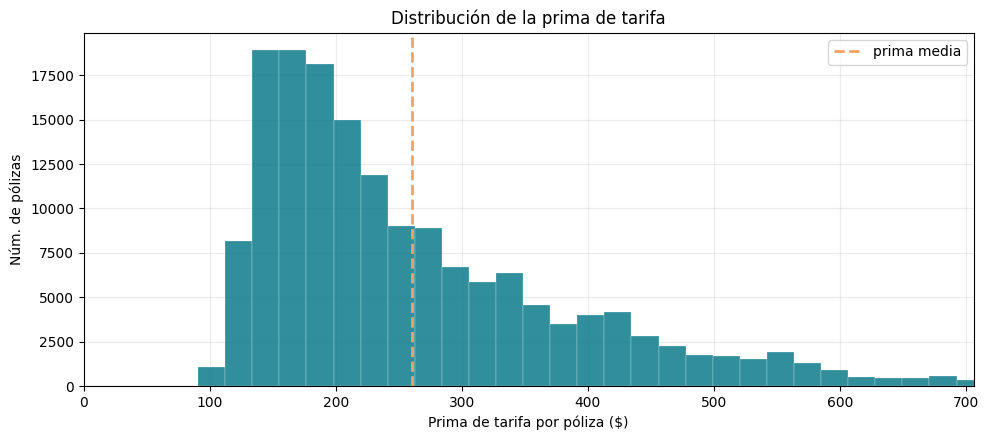

In [15]:
# ── Escenario: subir 8% la tarifa de jóvenes y bajar 3% a mayores de 55 ──────
d = datos.copy()
joven  = d['edad_conductor_cat'].astype(str).isin(['(17, 30]'])
mayor  = d['edad_conductor_cat'].astype(str).isin(['(55, 60]','(60, 95]'])
d.loc[joven, 'prima_tarifa'] *= 1.08
d.loc[mayor, 'prima_tarifa'] *= 0.97

nueva_total = (d['prima_tarifa']*d['exposicion']).sum()
comp = pd.DataFrame({
    'escenario':['Tarifa actual','Tarifa nueva'],
    'prima_total':[prima_tarifa_total, nueva_total],
    'variación_%':[0.0, (nueva_total/prima_tarifa_total-1)*100],
})
print(comp.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))

# Distribución de la prima de tarifa
fig, ax = plt.subplots(figsize=(10,4.5))
ax.hist(datos['prima_tarifa'], bins=60, color=AZUL, alpha=0.85, edgecolor='white', linewidth=0.2)
ax.axvline(np.average(datos.prima_tarifa,weights=datos.exposicion), ls='--', color=AMBAR, lw=2, label='prima media')
ax.set(xlabel='Prima de tarifa por póliza ($)', ylabel='Núm. de pólizas', title='Distribución de la prima de tarifa')
ax.set_xlim(0, datos.prima_tarifa.quantile(0.99)); ax.legend()
plt.tight_layout(); plt.show()

### 🎯 Ejercicio Integrador — Tu simulación de tarifa

1. Calcula la prima pura del portafolio (Frecuencia × Severidad) con los modelos cargados.
2. Conviértela a prima de tarifa con tus supuestos de gastos y margen.
3. Diseña un **escenario de tarifa** (ej. objetivo de recaudación, o ajuste por segmento) y mide
   su impacto agregado y por segmento.
4. Valida que la nueva tarifa sigue cubriendo la prima pura total (que no bajaste de costo).
5. En 3–4 líneas, documenta tu propuesta de tarifa como nota técnica.

*Solución en `solucion_integrador()`.*

In [16]:
# Scaffold — usa modelo_frec, modelo_sev y los supuestos GASTOS/MARGEN de arriba.

---
## Cierre — el tema completo, y lo que sigue

Cerraste el Tema 2: de un DataFrame a una **tarifa simulada**, pasando por la frecuencia, la
severidad, la selección de modelos, la validación fuera de muestra y la sensibilidad. Los tres
modelos guardados en la Sesión 2 fueron el insumo de todo lo de hoy.

**Lo que sigue.** Interpretar todas estas salidas —summary, rating factors, validación, sensibilidad—
es repetitivo. El siguiente paso es un **MCP** que interpreta las salidas del GLM por ti: le pasas el
modelo y te devuelve la lectura en lenguaje de nota técnica. Eso lo construimos aparte; hoy queda
mencionado como el puente hacia automatizar la interpretación.

**Y como evaluación del tema:** el reporte `evaluacion_M4T2.md` que integra las tres sesiones.